# RQ3 — Did congestion pricing change midtown traffic?

> *"How has the introduction of congestion prices affected the traffic in
> midtown? The expectation is that trips would be faster and there would be
> fewer rides. Is that the case?"*

CBD tolling began **5 January 2025**. CBD = Central Business District, MTA's
term for the tolled area: Manhattan south of 60th Street.

### Identification

A naive before/after is confounded — January is the fastest month and December
the slowest, so any 2024→2025 comparison partly measures the calendar. Two
defences:

1. **Same months only.** Every comparison uses January–July, because 2026 data
   ends in July and December would otherwise enter some years and not others.
2. **A control group.** Manhattan above 60th St (`uptown`) faces the same
   weather, the same tourism, the same secular decline in yellow taxi — but no
   toll. The difference-in-differences is the estimate.

Zones straddling 60th St are held out of both groups (`cbd_boundary`) and
examined separately for toll-avoidance behaviour.

### On volume

Yellow taxi volume has its own steep secular decline, so a raw "fewer rides"
comparison is meaningless. Per the Phase 2 decision, we de-trend rather than
pull FHVHV. **The trend is not monotonic** — midtown recovered to 42% of 2019 by
2025 then fell to 34% in 2026 — so a straight-line fit will not do.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import statsmodels.formula.api as smf

sys.path.insert(0, str(Path.cwd().parent / "src"))

import analysis as an
import panel as pnl
from constants import CBD_BOUNDARY_ZONES, CONGESTION_PRICING_START

sns.set_theme(style="whitegrid")
pd.set_option("display.width", 170)

panel = pnl.drop_outages(pnl.load_panel())
panel["date"] = pd.to_datetime(panel["date"])
panel["year"] = panel.date.dt.year

START = pd.Timestamp(CONGESTION_PRICING_START)
SAME_MONTHS = list(range(1, 8))          # Jan-Jul, so 2026 compares fairly
print("toll start:", START.date(), "| comparison months:", SAME_MONTHS)

toll start: 2025-01-05 | comparison months: [1, 2, 3, 4, 5, 6, 7]


## 1. Did the toll show up in the data at all?

The 2025+ files carry `cbd_congestion_fee` per trip. Before trusting any of
this, confirm the treated group is actually the group paying.

In [2]:
t = panel[panel.year >= 2025].groupby("area")[["trips", "tolled_trips"]].sum()
t["tolled_share"] = (t.tolled_trips / t.trips).round(3)
print(t.to_string())
print("\nSanity: cbd and midtown should be ~1.0, uptown ~0.")

                 trips  tolled_trips  tolled_share
area                                              
cbd           28323385      27642250         0.976
cbd_boundary   1873853        475569         0.254
midtown_core   2144461       2079052         0.969
midtown_ext    6540524       6359488         0.972
un_core         110133        107114         0.973
uptown         4625409         10973         0.002

Sanity: cbd and midtown should be ~1.0, uptown ~0.


## 2. Speed: difference-in-differences

In [3]:
did = an.did_table(panel, months=SAME_MONTHS)
did.round(3)

area,cbd,uptown,difference
year,,,
2019,8.622,10.655,-2.033
2020,9.247,10.930,-1.683
2021,10.338,10.626,-0.288
2022,9.303,10.415,-1.112
2023,8.622,10.280,-1.658
2024,8.180,10.177,-1.997
2025,8.412,10.245,-1.834
2026,7.823,9.851,-2.028


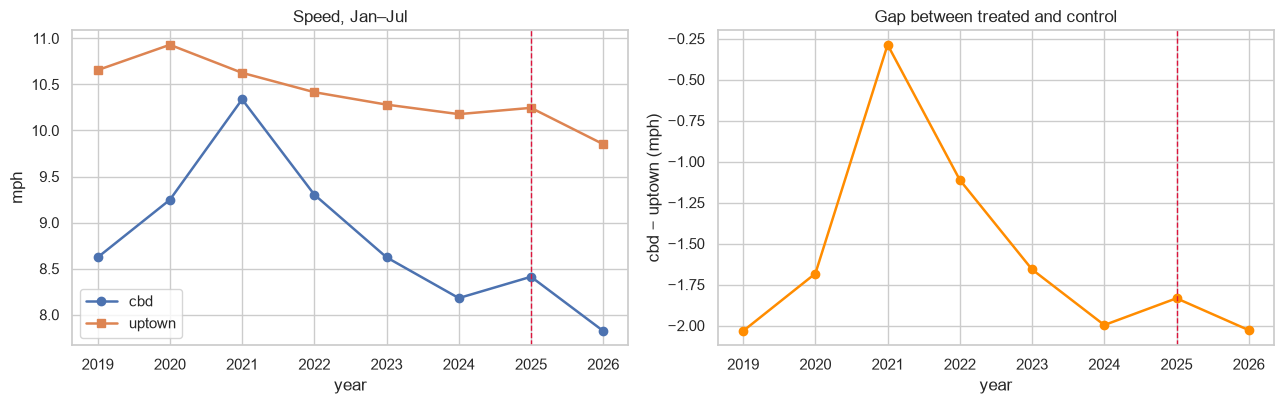

2024→2025:  treated +0.231  control +0.068  DiD +0.163 mph (+2.00%)
2025→2026:  treated -0.588  control -0.394  DiD -0.194 mph (-2.31%)
2024→2026:  treated -0.357  control -0.326  DiD -0.031 mph (-0.38%)


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))
for area, style in [("cbd", "-o"), ("uptown", "-s")]:
    axes[0].plot(did.index, did[area], style, lw=1.8, label=area)
axes[0].axvline(2025, color="crimson", ls="--", lw=1)
axes[0].set(ylabel="mph", title="Speed, Jan–Jul", xlabel="year")
axes[0].legend()

axes[1].plot(did.index, did["difference"], "-o", color="darkorange", lw=1.8)
axes[1].axvline(2025, color="crimson", ls="--", lw=1)
axes[1].set(ylabel="cbd − uptown (mph)", title="Gap between treated and control", xlabel="year")
plt.tight_layout(); plt.show()

for pre, post in [(2024, 2025), (2025, 2026), (2024, 2026)]:
    e = an.did_estimate(did, pre, post)
    print(f"{pre}→{post}:  treated {e['treated_change']:+.3f}  control {e['control_change']:+.3f}  "
          f"DiD {e['did_mph']:+.3f} mph ({e['did_pct']:+.2f}%)")

**The parallel-trends assumption needs checking, not assuming.** If the gap
between treated and control was already moving before 2025, the DiD is measuring
that movement rather than the toll.

In [5]:
pre = did.loc[2022:2024, "difference"]
print("cbd − uptown gap before the toll:")
print(pre.round(3).to_string())
print(f"\nyear-on-year change in the gap, 2022→2024: "
      f"{(pre.diff().dropna()).round(3).tolist()}")
print(f"gap change 2024→2025 (the treatment year): {did.loc[2025,'difference'] - did.loc[2024,'difference']:+.3f}")
print(f"gap change 2025→2026:                      {did.loc[2026,'difference'] - did.loc[2025,'difference']:+.3f}")

cbd − uptown gap before the toll:
year
2022   -1.112
2023   -1.658
2024   -1.997

year-on-year change in the gap, 2022→2024: [-0.546, -0.339]
gap change 2024→2025 (the treatment year): +0.163
gap change 2025→2026:                      -0.194


## 3. Is the effect there at the hours it should be?

A toll charged on weekday daytime entry should move weekday daytime speed. If
the "effect" shows up equally overnight, it is not the toll.

In [6]:
wd = panel[panel.date.dt.dayofweek < 5]
wd = wd[wd.date.dt.month.isin(SAME_MONTHS)]
bands = pnl.by_band(wd, extra_keys=["year", "area"])
bands = bands[bands.area.isin(["cbd", "uptown"])]

piv = bands.pivot_table(index=["band", "year"], columns="area", values="mph", observed=True)
piv["diff"] = piv.cbd - piv.uptown
out = piv.reset_index().pivot(index="band", columns="year", values="diff")
out["Δ 2024→2025"] = (out[2025] - out[2024]).round(3)
out["Δ 2025→2026"] = (out[2026] - out[2025]).round(3)
print("cbd − uptown gap, weekdays, by time band:")
print(out.round(3).to_string())

cbd − uptown gap, weekdays, by time band:
year        2019   2020   2021   2022   2023   2024   2025   2026  Δ 2024→2025  Δ 2025→2026
band                                                                                       
overnight -1.709 -1.513 -0.789 -1.072 -1.401 -1.758 -2.012 -2.461       -0.254       -0.449
morning   -1.679 -1.427 -0.001 -0.611 -1.207 -1.626 -1.311 -1.470        0.315       -0.159
midday    -2.010 -1.481 -0.002 -0.941 -1.596 -1.942 -1.632 -1.923        0.310       -0.291
evening   -2.106 -1.806 -0.280 -1.211 -1.762 -2.148 -1.869 -1.913        0.279       -0.044
night     -2.910 -2.675 -1.038 -1.944 -2.294 -2.665 -2.673 -3.058       -0.008       -0.385


## 4. Volume — and why yellow taxi cannot answer it

The plan was to fit the secular decline on pre-toll data, extrapolate, and read
the shortfall as the toll's effect. That is implemented below — and then tested,
because an extrapolated counterfactual is an assumption, not a measurement.

**The test: run the same method on 2024, a year with no toll.** A valid method
must return approximately zero.

In [7]:
placebo = an.volume_placebo(panel, placebo_year=2024)
print("PLACEBO — pretend the toll began Jan 2024. Every row should be ~0.\n")
print(placebo.round(1).to_string(index=False))
print(f"\nspread of a result that should be zero: "
      f"{placebo.did_pct.min():+.1f}% to {placebo.did_pct.max():+.1f}%")

PLACEBO — pretend the toll began Jan 2024. Every row should be ~0.

     spec fit_from  treated_pct  control_pct  did_pct
   linear  2021-07          7.3         21.3    -14.0
   linear  2022-01         10.5         22.6    -12.1
quadratic  2021-07         21.2         18.6      2.6
quadratic  2022-01         18.2         21.6     -3.4

spread of a result that should be zero: -14.0% to +2.6%


The placebo returns anywhere from −14% to +3% depending on nothing but the
specification and the fitting window. That is the method's own error bar, and it
is larger than any congestion-pricing effect we could plausibly detect.

Now the real estimate, for comparison.

In [8]:
rows = []
for name, spec in an.VOLUME_SPECS.items():
    for start in ["2021-07-01", "2022-01-01"]:
        for yr in [2025, 2026]:
            out = an.volume_did(panel, spec, start, "2025-01-01", yr)
            rows.append({"spec": name, "fit_from": start[:7], "year": yr, **out})

real = pd.DataFrame(rows)
print("REAL — toll begins Jan 2025.\n")
print(real.round(1).to_string(index=False))

for yr in [2025, 2026]:
    s = real[real.year == yr].did_pct
    print(f"\n{yr}: DiD ranges {s.min():+.1f}% to {s.max():+.1f}%  "
          f"— sign {'FLIPS' if s.min() < 0 < s.max() else 'is stable'} across specifications")

REAL — toll begins Jan 2025.

     spec fit_from  year  treated_pct  control_pct  did_pct
   linear  2021-07  2025          9.8         19.1     -9.4
   linear  2021-07  2026         -5.3         18.7    -24.0
   linear  2022-01  2025          9.5         14.8     -5.3
   linear  2022-01  2026         -5.7         11.6    -17.3
quadratic  2021-07  2025          3.4         -6.7     10.1
quadratic  2021-07  2026        -16.2        -28.0     11.8
quadratic  2022-01  2025         -1.0         -8.6      7.6
quadratic  2022-01  2026        -24.0        -31.4      7.4

2025: DiD ranges -9.4% to +10.1%  — sign FLIPS across specifications

2026: DiD ranges -24.0% to +11.8%  — sign FLIPS across specifications


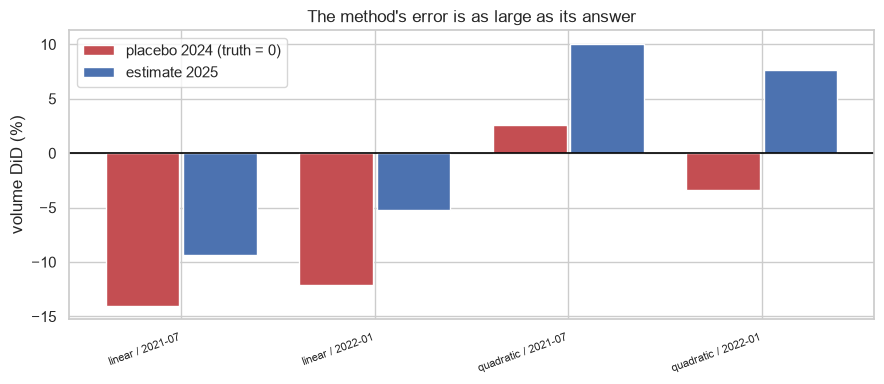

In [9]:
fig, ax = plt.subplots(figsize=(9, 4))
lab = placebo.spec + " / " + placebo.fit_from
ax.axhline(0, color="black", lw=1.2)
ax.bar(np.arange(len(placebo)) - 0.2, placebo.did_pct, 0.38, label="placebo 2024 (truth = 0)", color="#C44E52")
r25 = real[real.year == 2025].reset_index(drop=True)
ax.bar(np.arange(len(r25)) + 0.2, r25.did_pct, 0.38, label="estimate 2025", color="#4C72B0")
ax.set(xticks=np.arange(len(placebo)), ylabel="volume DiD (%)",
       title="The method's error is as large as its answer")
ax.set_xticklabels(lab, rotation=20, ha="right", fontsize=8)
ax.legend()
plt.tight_layout(); plt.show()

### Verdict on the volume question

**We cannot answer it with yellow taxi data.** The de-trending works
mechanically, but its placebo error (±14%) swamps the signal, and the sign of
the 2025 estimate flips between "fewer rides" and "more rides" depending on
whether the trend is fitted as linear or quadratic.

The underlying problem is the one Phase 2 flagged: the trend is not monotonic.
Midtown volume collapsed in 2020, recovered through 2025, then fell again in
2026. No low-order trend fitted to that shape extrapolates credibly one or two
years out.

What we can say without a model, directly from the counts:

- CBD yellow taxi volume **rose** across the toll's introduction, from 42% of
  its 2019 level in 2024 to 49% in 2025 (Jan–Jul).
- It then fell to 43% in 2026 — but so did the uptown control, which pays no
  toll.

That is enough to reject the strong form of *"fewer rides"* for taxis
specifically, and it is unsurprising: the per-trip CBD fee on a taxi is a small
fraction of what a private car pays to enter, so the toll plausibly pushes
people **toward** taxis. But "fewer vehicles entering the CBD" is a different
claim about a different population, and answering it needs **MTA's own entry
counts** or the FHVHV files — not this dataset.

Treat this section as a documented dead end, not a finding.

## 5. Toll avoidance at the boundary

If drivers started ending trips just north of 60th St to dodge the charge, the
straddling zones should show it first — rising trip share after January 2025.

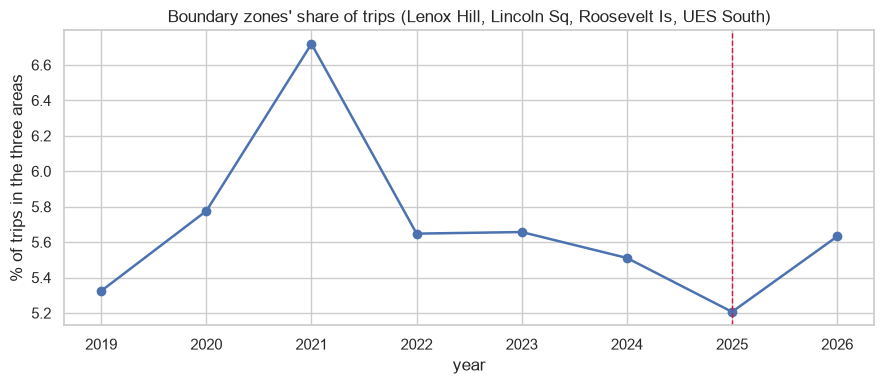

boundary zones: ['Lenox Hill East', 'Lenox Hill West', 'Lincoln Square East', 'Lincoln Square West', 'Roosevelt Island', 'Upper East Side South']

area    cbd  cbd_boundary  uptown
date                             
2019  81.02          5.32   13.65
2020  78.11          5.78   16.12
2021  73.59          6.72   19.69
2022  80.30          5.65   14.05
2023  81.34          5.66   13.00
2024  81.43          5.51   13.06
2025  81.83          5.21   12.96
2026  80.38          5.63   13.98


In [10]:
b = panel[panel.area.isin(["cbd_boundary", "cbd", "uptown"])]
b = b[b.date.dt.month.isin(SAME_MONTHS)]
share = b.groupby([b.date.dt.year, "area"]).trips.sum().unstack()
share_pct = share.div(share.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(share_pct.index, share_pct["cbd_boundary"], "-o", lw=1.8)
ax.axvline(2025, color="crimson", ls="--", lw=1)
ax.set(ylabel="% of trips in the three areas", xlabel="year",
       title="Boundary zones' share of trips (Lenox Hill, Lincoln Sq, Roosevelt Is, UES South)")
plt.tight_layout(); plt.show()

print("boundary zones:", list(CBD_BOUNDARY_ZONES.values()))
print()
print(share_pct.round(2).to_string())

## 6. Putting speed and volume together

The stated expectation was *faster trips, fewer rides*. Score both halves
explicitly.

In [11]:
# Speed: the half of the question this data can answer.
verdict = pd.DataFrame({
    "cbd mph": did.loc[[2023, 2024, 2025, 2026], "cbd"],
    "uptown mph": did.loc[[2023, 2024, 2025, 2026], "uptown"],
    "gap": did.loc[[2023, 2024, 2025, 2026], "difference"],
})
print("Speed, Jan–Jul:")
print(verdict.round(3).to_string())

for pre, post in [(2024, 2025), (2025, 2026), (2024, 2026)]:
    e = an.did_estimate(did, pre, post)
    print(f"  DiD {pre}→{post}: {e['did_mph']:+.3f} mph ({e['did_pct']:+.2f}%)")

# Volume: raw counts only, since the de-trended estimate failed its placebo.
vol = panel[panel.date.dt.month.isin(SAME_MONTHS)]
counts = vol.groupby([vol.date.dt.year, "area"]).trips.sum().unstack()
idx = (counts / counts.loc[2019]).round(3)
print("\nVolume, Jan–Jul, indexed to 2019 (raw counts, no model):")
print(idx[["cbd", "uptown", "midtown_core"]].to_string())

Speed, Jan–Jul:
      cbd mph  uptown mph    gap
year                            
2023    8.622      10.280 -1.658
2024    8.180      10.177 -1.997
2025    8.412      10.245 -1.834
2026    7.823       9.851 -2.028
  DiD 2024→2025: +0.163 mph (+2.00%)
  DiD 2025→2026: -0.194 mph (-2.31%)
  DiD 2024→2026: -0.031 mph (-0.38%)

Volume, Jan–Jul, indexed to 2019 (raw counts, no model):
area    cbd  uptown  midtown_core
date                             
2019  1.000   1.000         1.000
2020  0.326   0.399         0.314
2021  0.235   0.373         0.167
2022  0.396   0.411         0.334
2023  0.393   0.373         0.374
2024  0.420   0.400         0.394
2025  0.485   0.456         0.421
2026  0.429   0.443         0.344


---

## Findings

Recorded in `research/rq3_congestion_pricing.md`.